#### Import libraries

In [1]:
# import all of the necessary libraries

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np


In [2]:
# Make the training and the testing sets
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
# What type is this e.g. dataframe or list or array etc ?
type(X_train)

numpy.ndarray

In [4]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

This means this is a three dimensional array. There are 60,000 samples and each sample is a 28x28 matrix

In [5]:
# Whats the length of training and test sets ?
len(X_train), len(X_test)

(60000, 10000)

In [6]:
# To see the shape of the first element of the training set
X_train[0].shape

(28, 28)

In [7]:
# see the first element of the training set
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

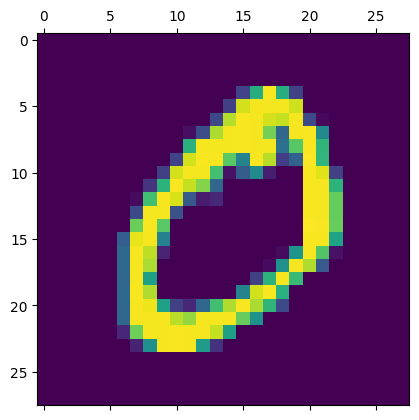

In [8]:
# We can see how the image looks like 

plt.matshow(X_train[1])

In [9]:
# y_train is the labels of what the matrix and the images look like
y_train[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

In [10]:
X_train.shape

(60000, 28, 28)

In [11]:
# As the colours are in the range from 0-255, we divide them so we can have numerical values 
X_train = X_train / 255
X_test = X_test / 255

In [12]:
# Flatten X trian and x test which are the shape of 2x2 matrix

X_train_flattened = X_train.reshape(len(X_train),28*28)
X_test_flattened = X_test.reshape(len(X_test),28*28)

In [13]:
X_train.shape

(60000, 28, 28)

In [14]:
# 28 x 28 = 784 
X_train_flattened.shape

(60000, 784)

In [15]:
X_train_flattened[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [ ]:
# Making the neural network model

# Sequential means layers are added one after another in order
model = keras.Sequential([

    # Dense = fully connected layer
    # Each neuron tries to predict one digit probability
    
    # This model has only ONE layer, so this is a very simple neural network
    keras.layers.Dense(
        10,                     # 10 neurons because MNIST has digits 0-9 (10 output classes)
        input_shape=(784,),     # 28x28 image becomes 784 values after flattening
        activation='sigmoid'    # sigmoid activation converts outputs into values between 0 and 1
    )
])

# Compile prepares the model for training
model.compile(

    # Optimizer controls how weights are updated during learning
    # Adam is a popular optimizer because it works well in many cases
    optimizer='adam',

    # sparse_categorical_crossentropy is used for multi-class classification
    # "sparse" means labels are integers like 0,1,2 instead of one-hot encoded
    loss='sparse_categorical_crossentropy',

    # accuracy tells us how many predictions were correct
    metrics=['accuracy']
)

# Train the model using training data
model.fit(

    # Input images flattened from 28x28 into 784 numbers
    X_train_flattened,

    # Correct answers/labels for each image
    y_train,

    # Entire dataset is passed through the network 5 times
    epochs=5
)

In [ ]:
# Making the neural network model here

# Define the model
model = keras.Sequential([
                        keras.layers.Dense(
                                            10,
                                            input_shape=(784,),
                                            activation='sigmoid'
                                        ) 
                        ])

# Compile the model
model.compile(
                optimizer='adam',                           # We can use different optimizers but for now we are just running the model
                loss = 'sparse_categorical_crossentropy',   # We can also tweak loss
                metrics = ['accuracy']                      # We can also tweak metrics too 
            )

# Fit the model
model.fit(
        X_train_flattened,  # Note the X_train is flattened
        y_train,            # y_train is normal
        epochs=5
        )

c:\Users\rehan\anaconda3\envs\py3114\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 560us/step - accuracy: 0.8772 - loss: 0.4695
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 585us/step - accuracy: 0.9150 - loss: 0.3030
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 555us/step - accuracy: 0.9207 - loss: 0.2827
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 549us/step - accuracy: 0.9233 - loss: 0.2729
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 548us/step - accuracy: 0.9256 - loss: 0.2667


In [ ]:
model.evaluate(X_test_flattened, y_test)

In [ ]:
plt.matshow(X_test[1])

In [ ]:
y_predicted = model.predict(X_test_flattened)
y_predicted[0]

In [ ]:
np.argmax(y_predicted[1])

In [ ]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]
y_predicted_labels[:5]

In [ ]:
cm = tf.math.confusion_matrix(
                            labels=y_test, 
                            predictions=y_predicted_labels
                            )

In [ ]:
cm

In [ ]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,), activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train_flattened, y_train, epochs=5)

In [ ]:
model.evaluate(X_test_flattened, y_test)

In [ ]:
y_predicted = model.predict(X_test_flattened)
y_predicted_labels = [np.argmax(i) for i in y_predicted]
cm = tf.math.confusion_matrix(
                                labels=y_test,
                                predictions=y_predicted_labels
                            )

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [ ]:
# Use the keras flatten function in here

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='Adadelta',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)


In [ ]:
model.evaluate(X_test, y_test)

Random question, can you make a smiley in matric and then show it in the matplot ?

In [ ]:
random_matrix = np.random.randint(0,256,(28,28))
# Create empty 28x28 matrix
smiley = np.zeros((28,28))

# Face
for i in range(28):
    for j in range(28):
        if (i-14)**2 + (j-14)**2 < 12**2:
            smiley[i,j] = 255

# Eyes
smiley[9:12, 9:12] = 0
smiley[9:12, 17:20] = 0

# Smile
for j in range(8,21):
    smiley[20, j] = 0

smiley[19,8] = 0
smiley[18,7] = 0

smiley[19,20] = 0
smiley[18,21] = 0

# Show image
plt.matshow(smiley,)
plt.show()